# On Analyzing Real World Time Series using the Wesad Dataset

[WESAD (Wearable Stress and Affect Detection)](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os

import numpy as np
import pandas as pd

from tqdm import tqdm

from scipy.signal import butter, lfilter
# Get the current working directory of the notebook
notebook_dir = os.getcwd()

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Chest and Wrist Data

- Synchronised raw sensor data and labels

### Data Attributes

- Chest: RespiBAN device
    - Sampled at 700 Hz
    1. **ACC_x:**
    2. **ACC_y:**
    3. **ACC_z:**
    4. **ECG:**
    5. **EMG:**
    6. **EDA:**
    7. **Temp:**
    8. **Resp:**
    9. **Subject:** The participant in the study
    10. **Label:** ID of the respective study protocol condition
        - 0 = not defined / transient
        - 1 = baseline
        - 2 = stress
        - 3 = amusement
        - 4 = meditation
        - 5/6/7 = should be ignored in this dataset
- Wrist: Empatica E4 device


In [3]:
def build_wesad() -> list[pd.DataFrame]:
    """Load the WESAD Dataset"""
    base_path = "../../"
    
    chest_dataset_path = "roeh-health/data/WESAD/all_subjects/chest.csv"
    wrist_dataset_path = "roeh-health/data/WESAD/all_subjects/wrist.csv"
    
    chest_relative_path = os.path.join(base_path, chest_dataset_path)
    wrist_relative_path = os.path.join(base_path, wrist_dataset_path)

    chest_df = pd.read_csv(chest_relative_path)
    wrist_df = pd.read_csv(wrist_relative_path)

    chest_df.drop(['Unnamed: 0'], axis=1, inplace=True)
    wrist_df.drop(['Unnamed: 0'], axis=1, inplace=True)

    return chest_df, wrist_df

In [4]:
chest_df, wrist_df = build_wesad()

## Get ECG

In [5]:
chest_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [6]:
ecg_df = chest_df.loc[:, ['ECG', 'subject', 'label']]
ecg_df

,ECG,subject,label
0,0.021423,S2,0
1,0.020325,S2,0
2,0.016525,S2,0
3,0.016708,S2,0
4,0.011673,S2,0
...,...,...,...
60807595,0.173676,S17,0
60807596,0.168777,S17,0
60807597,0.167130,S17,0
60807598,0.170334,S17,0


In [7]:
ecg_values = ecg_df['ECG'].to_numpy()
ecg_values

array([0.02142334, 0.02032471, 0.01652527, ..., 0.16712952, 0.17033386,
       0.17523193], shape=(60807600,))

## Bandpass Filter

- Type: Butterworth
- Goal: Remove frequences outside range and amplify those within range
- Range: 

In [8]:
def bandpass_filter(data: np.array,
                    lower_range: int,
                    upper_range: int, 
                    sampling_rate: float,
                    order: int,
                    filter_type: str = 'Butterworth') -> pd.DataFrame:
        """
        Apply a bandpass filter to the input data.
    
        Parameters
        ----------
        lower_range : float
            The lower cutoff frequency of the bandpass filter.
        upper_range : float
            The upper cutoff frequency of the bandpass filter.
        sampling_rate : float
            The sampling frequency of the signal. 
            See update_with_sampling_rate() and avg_down_sample() for explanations.
        order : int, optional
            The order of the filter (default is 5).
        filter_type : str, optional
            The type of filter to apply (default is 'Butterworth'). 
            Supported types are 'Butterworth', 'Chebyshev1', 'Chebyshev2', and 'Bessel'.
        
        Returns
        -------
        UnivariateTimeSeries
            The filtered signal data.
        
        Raises
        ------
        ValueError
            If an improper filter type is selected.

        Notes
        -----
        Filter in general takes in some data, perform some manipulations, then output the data.
        Butterworth filter specificially magnifies data within range and excludes data NOT in range
            as it's considered noise.
        
        """
        filter_type = filter_type.lower()
        
        if filter_type == 'butterworth':
            nyquist = 0.5 * sampling_rate
            low = lower_range / nyquist
            high = upper_range / nyquist
            b, a = butter(order, [low, high], btype='band')
            y = lfilter(b, a, data)
            return y
        elif filter_type == 'chebyshev1':
            # Placeholder for Chebyshev Type I filter
            pass
        elif filter_type == 'chebyshev2':
            # Placeholder for Chebyshev Type II filter
            pass
        elif filter_type == 'bessel':
            # Placeholder for Bessel filter
            pass
        else:
            raise ValueError("Improper filter type selection. Choose from: Butterworth, Chebyshev1, Chebyshev2, Bessel")



In [9]:
lower_bound = 0.7
upper_bound = 4.0
sampling_rate = 700  # Hz
order = 5

post_bandpass_ecg = bandpass_filter(ecg_values, lower_bound, upper_bound, sampling_rate, order)
post_bandpass_ecg

array([1.45565780e-11, 1.57964303e-10, 8.60344587e-10, ...,
                  nan,            nan,            nan], shape=(60807600,))

In [10]:
# Set display option for scientific notation
pd.set_option("display.float_format", "{:.2e}".format)

ecg_df['Post Bandpass'] = post_bandpass_ecg
ecg_df

,ECG,subject,label,Post Bandpass
0,2.14e-02,S2,0,1.46e-11
1,2.03e-02,S2,0,1.58e-10
2,1.65e-02,S2,0,8.60e-10
3,1.67e-02,S2,0,3.19e-09
4,1.17e-02,S2,0,9.16e-09
...,...,...,...,...
60807595,1.74e-01,S17,0,NaN
60807596,1.69e-01,S17,0,NaN
60807597,1.67e-01,S17,0,NaN
60807598,1.70e-01,S17,0,NaN


### Plot Bandpass Filter Here

In [13]:
filt_s2 = (ecg_df['subject'] == 'S2')
s2_df = ecg_df[ecg_df[filt_s2]]
s2_df

ValueError: Boolean array expected for the condition, not object

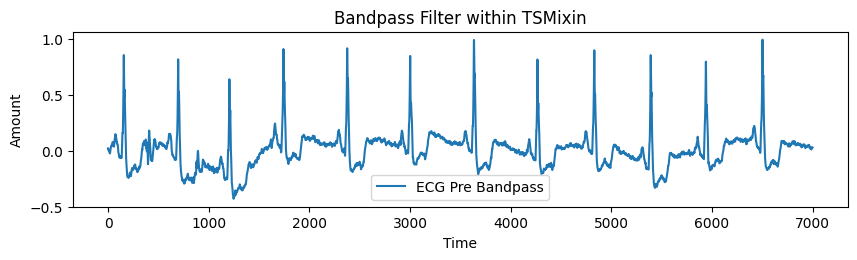

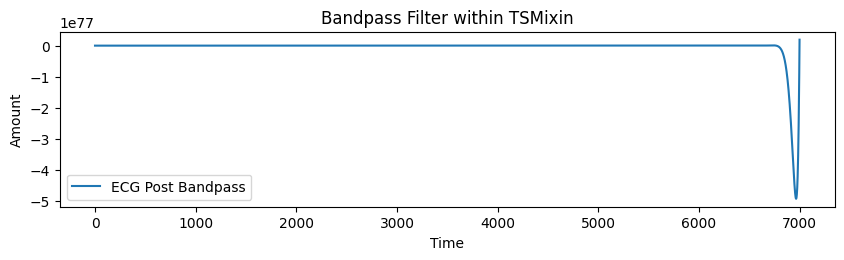

In [11]:
import matplotlib.pyplot as plt

# Plotting the original and filtered stock price data
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(ecg_df['ECG'].to_numpy()[:7000], label='ECG Pre Bandpass')
plt.title('Bandpass Filter within TSMixin')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()

# Plotting the original and filtered stock price data
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(ecg_df['Post Bandpass'].to_numpy()[:7000], label='ECG Post Bandpass')
plt.title('Bandpass Filter within TSMixin')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()

### Plot Bandpass Filter Using TSLearn

In [ ]:
PlotFactory.plot_bandpass(base_ts=ecg_uts, 
                          limit=7000, 
                          data_units_xaxis='Time', 
                          data_units_yaxis='Amount', 
                          pre_or_post='Pre',
                          data_name='ECG')

PlotFactory.plot_bandpass(base_ts=post_bandpass_uts, 
                          limit=7000, 
                          data_units_xaxis='Time', 
                          data_units_yaxis='Amount', 
                          pre_or_post='Post',
                          data_name='ECG')

## Peak Detection

In [ ]:
all_peaks = post_bandpass_uts.detect_peak('all', sampling_rate)
all_peaks

### Plot Peaks Using TSLearn

In [ ]:
PlotFactory.plot_peaks(post_bandpass_uts, all_peaks, 'wfdb_peaks', sampling_rate, 'seconds', 'mV')
PlotFactory.plot_peaks(post_bandpass_uts, all_peaks, 'neurokit_peaks', sampling_rate, 'seconds', 'mV')